In [1]:
from main.scheduler import EDMScheduler
import matplotlib.pyplot as plt

from omegaconf import OmegaConf
import torch

In [2]:
#Load a scheduler using a config file
daps_config_yaml = 'configs/daps_config/edm_daps.yaml'
daps_config = OmegaConf.load(daps_config_yaml)

In [3]:
#Load a model using a config file
from model import get_model
model_config_yaml = 'configs/model/ffhq256ddpm.yaml'
model_config = OmegaConf.load(model_config_yaml)
model = get_model(**model_config)

/home/wally/DD2610-Project/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
#Load a dataset using a config file
from data import get_dataset
dataset_config_yaml = 'configs/data/ffhq_debug.yaml'
dataset_config = OmegaConf.load(dataset_config_yaml)
dataset = get_dataset(**dataset_config)
images = dataset.get_data(1)


In [5]:
from torchvision.utils import save_image
import PIL
def visualize_grid(images, target='image.png', nrow=10, figsize=None, normalize=True):
    # Save images.
    save_grid(images, target, nrow=nrow, normalize=normalize)
    visualize_pil(target, figsize=figsize)


def save_grid(images, target='image.png', nrow=10, normalize=True):
    # Save images.
    if normalize:
        images = norm_image_01(images)
    save_image(images, target, nrow=nrow)

def norm_image_01(x):
    return (x * 0.5 + 0.5).clip(0, 1)

def visualize_pil(target, figsize=None):
    pil_image = PIL.Image.open(target)
    if figsize is None:
        plt.figure(figsize=(3, 3))
    else:
        plt.figure(figsize=figsize)
    plt.imshow(pil_image)
    plt.axis('off')  # Turn off axis numbers and ticks
    plt.show()




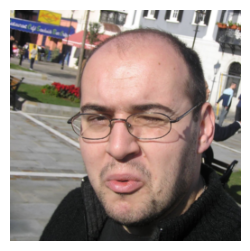

In [6]:
visualize_grid(images, nrow=10)

In [7]:
#Load an operator using a config file
task_config_yaml = 'configs/task/phase_retrieval.yaml'
task_group = 'pixel'
task_config = OmegaConf.load(task_config_yaml)
mcmc_sampler_config = task_config[task_group].mcmc_sampler_config
operator_config = task_config[task_group].operator


In [8]:
mcmc_sampler_config

{'num_steps': 100, 'lr': 5e-05, 'tau': 0.01, 'lr_min_ratio': 0.01, 'mc_algo': 'langevin', 'prior_solver': 'gaussian'}

In [9]:
from forward_operator import get_operator
operator = get_operator(**operator_config)
measurement = operator.measure(images)

In [10]:
from torch.nn.functional import interpolate

def resize(y, x, task_name):
    if y.shape != x.shape:
        ry = interpolate(y, size=x.shape[-2:], mode='bilinear', align_corners=False)
    else:
        ry = y
    if task_name == 'phase_retrieval':
        def norm_01(y):
            tmp = (y - y.mean()) / y.std()
            tmp = tmp.clip(-0.5, 0.5) * 3
            return tmp

        ry = norm_01(ry) * 2 - 1
    return ry

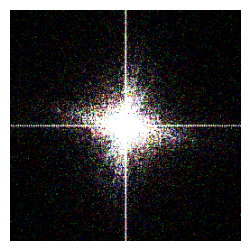

In [11]:
#Measurement works
resized_measurement = resize(measurement, images, operator_config.name)
visualize_grid(resized_measurement, nrow=5)

In [12]:
daps_config

{'latent': False, 'annealing_scheduler_config': {'name': 'edm', 'num_steps': 200, 'sigma_max': 100, 'sigma_min': 1, 'timestep': 'poly-7'}, 'diffusion_scheduler_config': {'name': 'edm', 'num_steps': 5, 'sigma_min': 0.01, 'timestep': 'poly-7'}}

In [13]:
num_steps = 5
edmsampler1 = EDMScheduler(num_steps)
t = edmsampler1.get_discrete_time_steps(num_steps)
sigma = edmsampler1.get_sigma(t)

#To check if pfode.py is working
from main.pfode import PFODE
pf_ode = PFODE(edmsampler1, model, (1, *images[0].shape))
x_T = pf_ode.gaussian_prior_x_T(1)
x_0 = pf_ode.solve(x_T)

In [14]:
#To check if DAPS is working
from daps_sampler import DAPS
daps = DAPS(daps_config['annealing_scheduler_config'], daps_config['diffusion_scheduler_config'], mcmc_sampler_config)

x_init = daps.gaussian_prior_x_T(1, model.get_in_shape(), next(model.parameters()).device)
#x_init = pf_ode.gaussian_prior_x_T(1)
x_final = daps.daps_sample(model, x_init, operator, measurement, True)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [02:26<00:00,  1.36it/s]


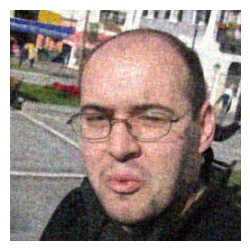

In [15]:
visualize_grid(x_final, nrow=5)

In [18]:
len(daps.record_data['x0_conds'])

200

In [19]:
x0_hats = [img.squeeze(0) for img in daps.record_data['x0_hats']]
x0_hats = torch.stack(x0_hats, dim=0)

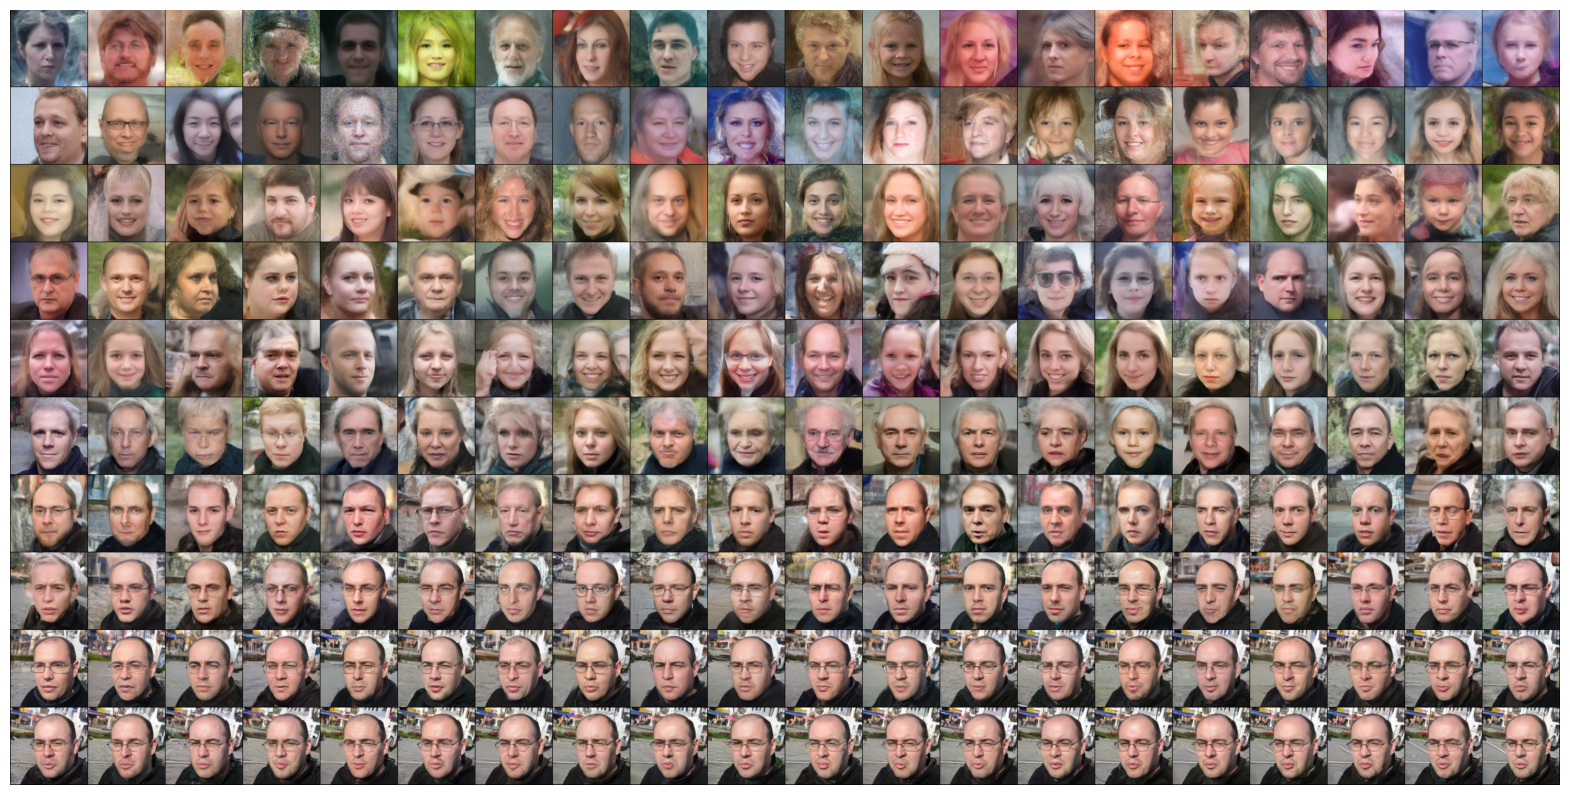

In [20]:
visualize_grid(x0_hats, nrow=20, figsize=(20, 20))

In [17]:
#x_init.shape

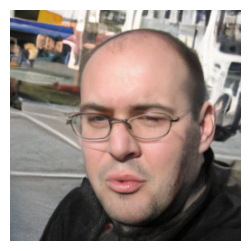

In [22]:
visualize_grid(x0_hats[-1,:,:,:], nrow=5)

In [16]:
#visualize_grid(x_init, nrow=5)

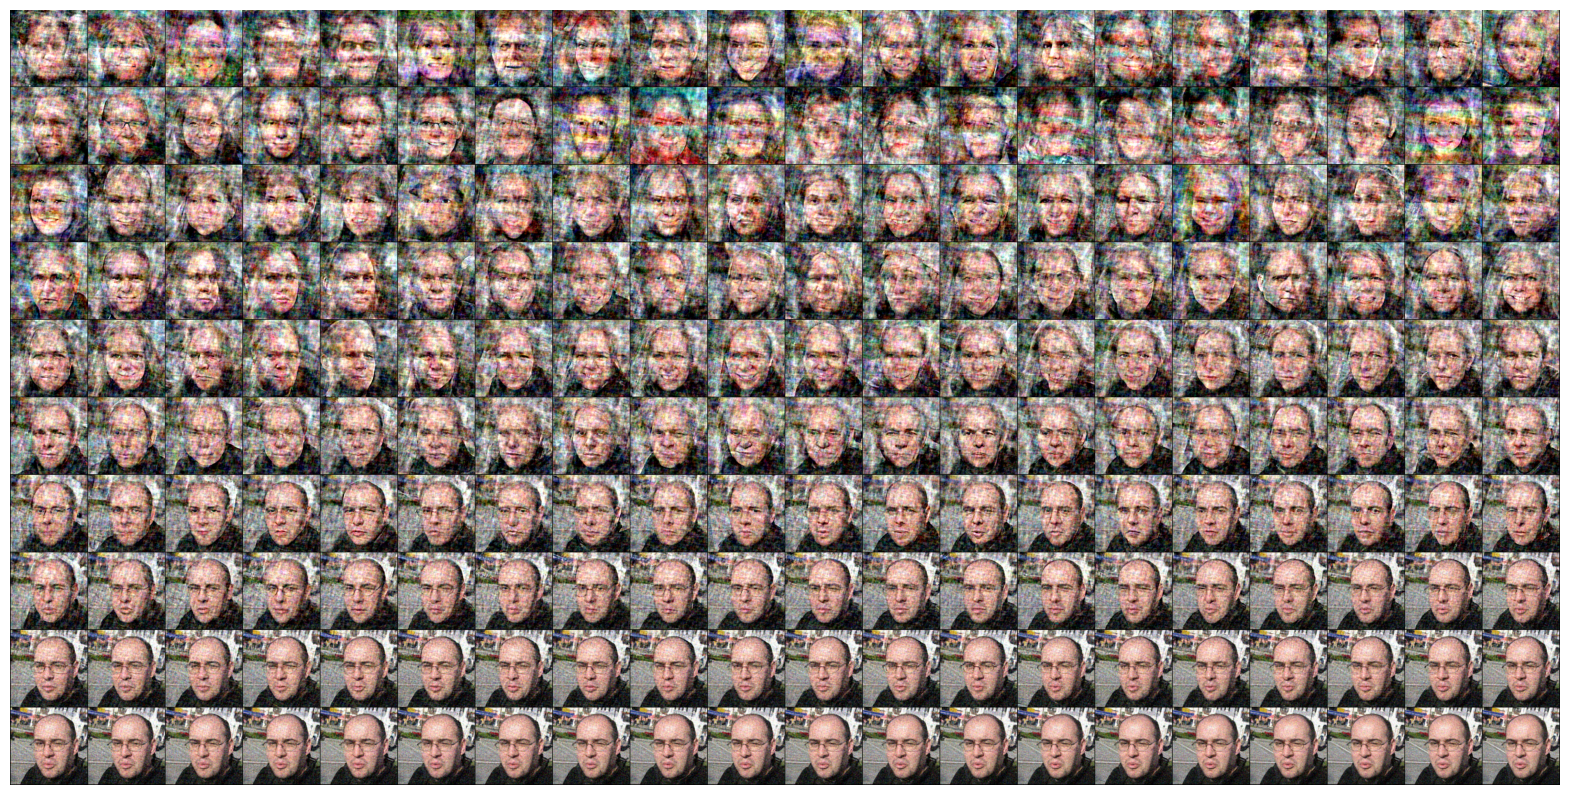

In [21]:
x0_conds = [img.squeeze(0) for img in daps.record_data['x0_conds']]
x0_conds = torch.stack(x0_conds, dim=0)
visualize_grid(x0_conds, nrow=20, figsize=(20, 20), target="cond_155.png")